In [1]:
pip install python-pptx

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


## Автоматизация процесса получения аналитики по РДП

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from datetime import datetime

from pptx import Presentation
from pptx.util import Inches
import os
import shutil

%matplotlib inline
import matplotlib.pyplot as plt

In [3]:
# получаем данные

path = 'рдп_данные_29_06.xlsx'
df = pd.read_excel(path)

### Аналитика по РДП

C:\Users\gazizova.dg\AppData\Local\Temp\ipykernel_11208\3170971051.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_prev.sort_values(by = df_prev.columns[1], inplace = True)
C:\Users\gazizova.dg\AppData\Local\Temp\ipykernel_11208\3170971051.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cur.sort_values(by = df_cur.columns[1], inplace = True)


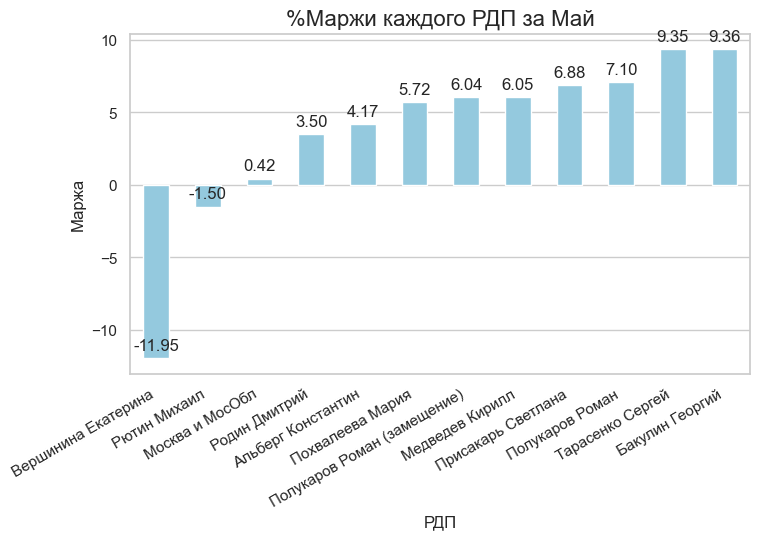

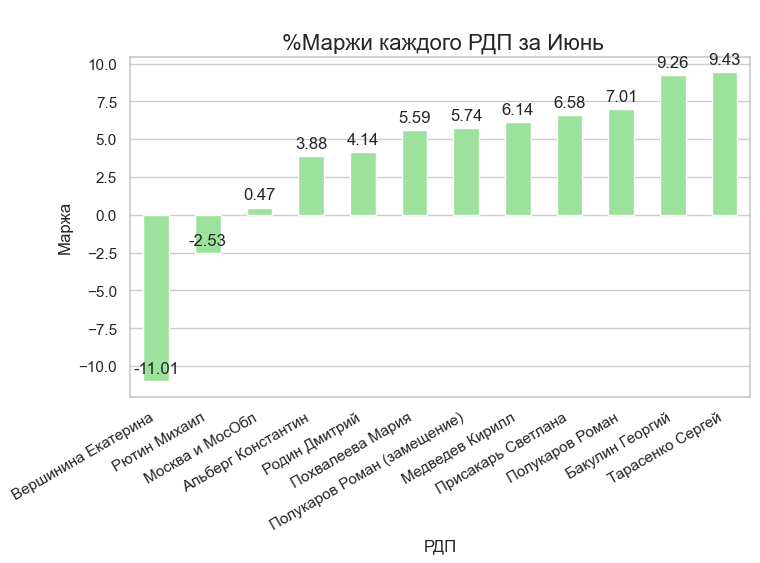

C:\Users\gazizova.dg\AppData\Local\Temp\ipykernel_11208\3170971051.py:69: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fill_df_prev.drop(columns = fill_df_prev.columns[2], inplace = True)
C:\Users\gazizova.dg\AppData\Local\Temp\ipykernel_11208\3170971051.py:70: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fill_df_cur.drop(columns = fill_df_cur.columns[2], inplace = True)


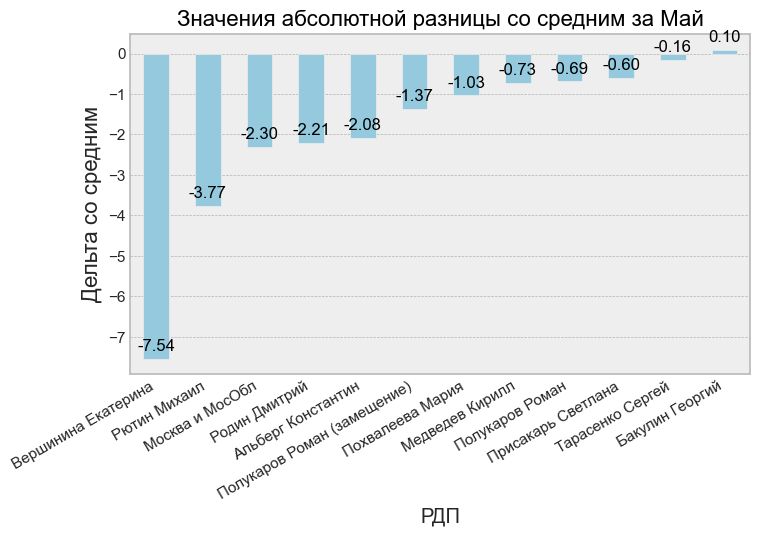

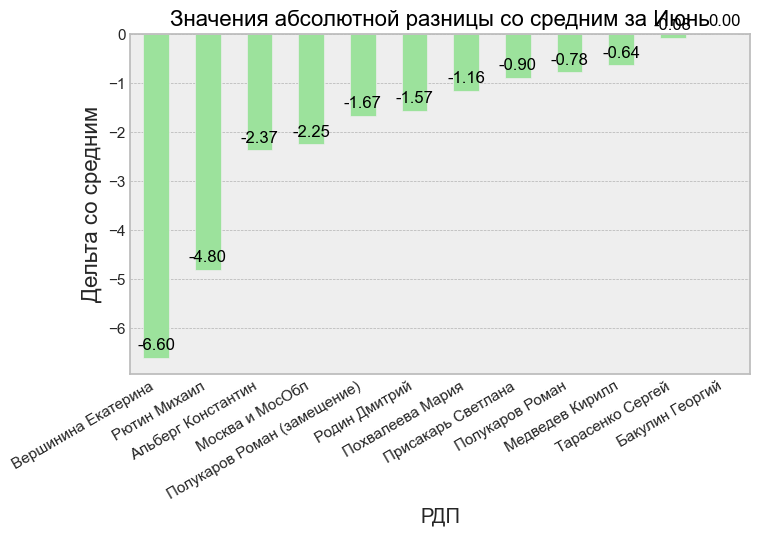

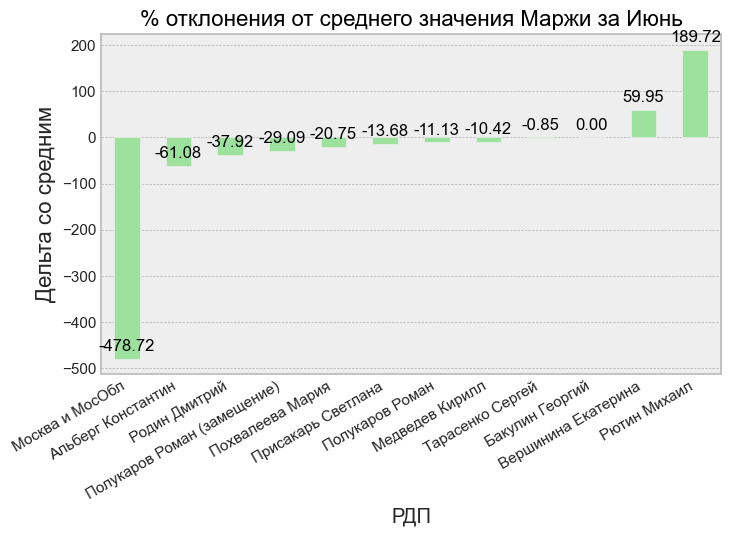

,РДП,Июнь,Среднee (2024г),Абс. разница Июнь,%разницы Июнь
11,Вершинина Екатерина,-11.01,-4.41,-6.60,59.95
9,Рютин Михаил,-2.53,2.27,-4.80,189.72
0,Альберг Константин,3.88,6.25,-2.37,-61.08
3,Москва и МосОбл,0.47,2.72,-2.25,-478.72
5,Полукаров Роман (замещение),5.74,7.41,-1.67,-29.09
8,Родин Дмитрий,4.14,5.71,-1.57,-37.92
6,Похвалеева Мария,5.59,6.75,-1.16,-20.75
7,Присакарь Светлана,6.58,7.48,-0.90,-13.68
4,Полукаров Роман,7.01,7.79,-0.78,-11.13
2,Медведев Кирилл,6.14,6.78,-0.64,-10.42


In [4]:
def analyse_rdp(df, a='Май', b='Июнь', prev_month='2025-05', current_month='2025-06'):
    # даты
    full_month_range = pd.period_range(start = (df.iloc[:,2]).iloc[0],
                                    end = (df.iloc[:,2]).iloc[-1],
                                    freq = 'M').strftime('%Y-%m')
    # Получение текущей даты и времени
    now = datetime.now().strftime('%Y-%m-%d')

    # находим среднее значение по каждому РДП
    for i in df.iloc[:,0].unique():
        filtred_df = df[df.iloc[:,0] == i]
        filtred_df = filtred_df.iloc[:,1:3]
        filtred_df.iloc[:,0] = round(filtred_df.iloc[:,0] * 100, 2)
        mean = filtred_df.query("МесяцВыдачи < '2025-00'").iloc[:,0].mean()

    
    #выводим ранжированный список РДП за 2 последних месяца:
    df_prev = df[df.iloc[:,2] == prev_month]
    df_cur = df[df.iloc[:,2] == current_month]

    df_prev.iloc[:,1] = round(df_prev.iloc[:,1] * 100, 2)
    df_cur.iloc[:,1] = round(df_cur.iloc[:,1] * 100, 2)

    df_prev.sort_values(by = df_prev.columns[1], inplace = True)
    df_cur.sort_values(by = df_cur.columns[1], inplace = True)

    # выводим список РДП за октябрь и ноябрь
    df_prev
    df_cur

    # Графики Ранжирования РДП на предыдущий месяц

    sns.set(style = 'whitegrid')
    plt.figure(figsize = (8,5))
    ax = sns.barplot(x = df_prev.columns[0], y = df_prev.columns[1], data = df_prev, color='skyblue', width=0.5)
    plt.gcf().autofmt_xdate()
    plt.title(f'%Маржи каждого РДП за {a}', fontsize = 16)

    for p in ax.patches:
        ax.annotate(format(p.get_height(), '.2f'), (p.get_x() + p.get_width() / 2., p.get_height()), ha = 'center', va = 'center', xytext = (0,9), textcoords = 'offset points')

    # Сохраняем диаграммы
    name_pic1 = f'Маржа_{a}_{now}'
    plt.savefig(f'{name_pic1}.png')
    plt.show()

    # Ранжирование РДП на текущий месяц

    sns.set(style = 'whitegrid')

    plt.figure(figsize = (8,5))
    ax = sns.barplot(x = df_cur.columns[0], y = df_cur.columns[1], data = df_cur, color='lightgreen', width=0.5)
    plt.gcf().autofmt_xdate()
    plt.title(f'\n %Маржи каждого РДП за {b}', fontsize = 16)

    for p in ax.patches:
        ax.annotate(format(p.get_height(), '.2f'), (p.get_x() + p.get_width() / 2., p.get_height()), ha = 'center', va = 'center', xytext = (0,9), textcoords = 'offset points')

    # Сохраняем диаграммы
    name_pic2 = f'Маржа_{b}_{now}'
    plt.savefig(f'{name_pic2}.png')
    plt.show()

    # находим средние значения и сравним их со значениями последних двух месяцев

    fill_df_prev = df[df[df.columns[2]].isin([prev_month])]
    fill_df_cur = df[df[df.columns[2]].isin([current_month])]

    fill_df_prev.drop(columns = fill_df_prev.columns[2], inplace = True)
    fill_df_cur.drop(columns = fill_df_cur.columns[2], inplace = True)

    filtred_mask = (df.iloc[:,2] >= '2024-01') & (df.iloc[:,2] <= '2024-12')
    mean_marg = df.loc[filtred_mask].groupby(df.columns[0])[df.columns[1]].mean().reset_index()

    df_RE_prev = pd.merge(fill_df_prev, mean_marg, on = df.columns[0])
    df_RE_cur = pd.merge(fill_df_cur, mean_marg, on = df.columns[0])

    # приводим данные к нормальному виду

    df_RE_prev.rename(columns = {df_RE_prev.columns[1] : f'{a}'}, inplace = True)
    df_RE_cur.rename(columns = {df_RE_cur.columns[1] : f'{b}'}, inplace = True)
    df_RE_prev.rename(columns = {df_RE_prev.columns[2] : 'Среднee (2024г)'}, inplace = True)
    df_RE_cur.rename(columns = {df_RE_cur.columns[2] : 'Среднee (2024г)'}, inplace = True)

    df_RE_prev.iloc[:,1] = df_RE_prev.iloc[:,1] * 100
    df_RE_cur.iloc[:,1] = df_RE_cur.iloc[:,1] * 100

    df_RE_prev.iloc[:,2] = round(df_RE_prev.iloc[:,2] * 100 , 2)
    df_RE_cur.iloc[:,2] = round(df_RE_cur.iloc[:,2] * 100 , 2)

    # находим абсолютную и относительную (%) разницу предыдущего месяца со средними значениями

    df_RE_prev[f'Абс. разница {a}'] = round((df_RE_prev.iloc[:,1] - df_RE_prev.iloc[:,2]), 2)
    df_RE_prev[f'%разницы {a}'] = round((df_RE_prev[f'Абс. разница {a}'] / df_RE_prev.iloc[:,1])*100, 2)
    df_RE_prev.sort_values(by = df_RE_prev.columns[1], inplace = True)
    df_RE_prev

    # находим абсолютную и относительную (%) разницу текущего месяца со средними значениями

    df_RE_cur[f'Абс. разница {b}'] = round((df_RE_cur.iloc[:,1] - df_RE_cur.iloc[:,2]), 2)
    df_RE_cur[f'%разницы {b}'] = round((df_RE_cur[f'Абс. разница {b}'] / df_RE_cur.iloc[:,1])* 100, 2)
    df_RE_cur.sort_values(by = df_RE_cur.columns[1], inplace = True)
    df_RE_cur

    # график Значения абсолютной разницы со средним за предыдущий месяц

    plt.style.use('bmh')
    plt.figure(figsize = (8,5))
    ax = sns.barplot(x = df_RE_prev.columns[0], y = df_RE_prev.columns[3], data = df_RE_prev.sort_values(by = df_RE_prev.columns[3]), color='skyblue', width=0.5)
    plt.gcf().autofmt_xdate()
    plt.title(f'Значения абсолютной разницы со средним за {a}', color = 'black', fontsize = 16)

    for p in ax.patches:
        ax.annotate(format(p.get_height(), '.2f'), (p.get_x() + p.get_width() / 2., p.get_height()), ha = 'center', va = 'center', xytext = (0,9), textcoords = 'offset points', color = 'black')
    #plt.xlabel('РДП', fontsize = 16)
    plt.ylabel('Дельта со средним', fontsize = 16)

    # Сохраняем диаграммы
    name_pic3 = f'Дельта_{a}_{now}'
    plt.savefig(f'{name_pic3}.png')
    plt.show()

    # график Значения абсолютной разницы со средним за текущий месяц

    plt.style.use('bmh')
    plt.figure(figsize = (8,5))
    ax = sns.barplot(x = df_RE_cur.columns[0], y = df_RE_cur.columns[3], data = df_RE_cur.sort_values(by = df_RE_cur.columns[3]), color='lightgreen', width=0.5)
    plt.gcf().autofmt_xdate()
    plt.title(f'Значения абсолютной разницы со средним за {b}', color = 'black', fontsize = 16)

    for p in ax.patches:
        ax.annotate(format(p.get_height(), '.2f'), (p.get_x() + p.get_width() / 2., p.get_height()), ha = 'center', va = 'center', xytext = (0,9), textcoords = 'offset points', color = 'black')
    #plt.xlabel('РДП', fontsize = 16)
    plt.ylabel('Дельта со средним', fontsize = 16)

    # Сохраняем диаграммы
    name_pic4 = f'Дельта_{b}_{now}'
    plt.savefig(f'{name_pic4}.png')
    plt.show()

    # график Значения относительной разницы со средним за текущий месяц

    plt.style.use('bmh')
    plt.figure(figsize = (8,5))
    ax = sns.barplot(x = df_RE_cur.columns[0], y = df_RE_cur.columns[4], data = df_RE_cur.sort_values(by = df_RE_cur.columns[4]), color='lightgreen', width=0.5)
    plt.gcf().autofmt_xdate()
    plt.title(f'% отклонения от среднего значения Маржи за {b}', color = 'black', fontsize = 16)

    for p in ax.patches:
        ax.annotate(format(p.get_height(), '.2f'), (p.get_x() + p.get_width() / 2., p.get_height()), ha = 'center', va = 'center', xytext = (0,9), textcoords = 'offset points', color = 'black')
    #plt.xlabel('РДП', fontsize = 16)
    plt.ylabel('Дельта со средним', fontsize = 16)

    # Сохраняем диаграммы
    name_pic5 = f'Дельта_относ_{b}_{now}'
    plt.savefig(f'{name_pic5}.png')
    plt.show()

    # Сохраняем обработанные данные в новом файле Excel

    output_file = f'Маржа_РДП_дельта.xlsx'
    df_RE_prev.to_excel(output_file, sheet_name=f'РДП_{a}', index=False)
    df_RE_cur.to_excel(output_file, sheet_name=f'РДП_{b}', index=False)

   # Сохранение полученных диаграмм и таблиц в одной папке

    # Создаем папку для результатов
    result_folder = f'RDP_analytics_{now}'
    os.makedirs(result_folder, exist_ok=True)

    # Перемещаем файлы в созданную папку
    shutil.move(output_file, result_folder)
    for file in os.listdir():
        if file.endswith('.png'):
            shutil.move(file, result_folder)

    return df_RE_cur.sort_values(by = df_RE_cur.columns[3])

# Вывод рез-та
analyse_rdp(df)

### Графики Динамики по каждому РДП

In [5]:
def margin_rdp(df):
    # Создаем новую презентацию
    prs = Presentation()
    
    # Получение текущей даты для названия папки и файлов
    now = datetime.now().strftime('%Y-%m-%d')
    
    # Название папки
    output_folder = f'RDP_analytics_{now}'
    
    # Проверяем, существует ли папка. Если нет — создаем её
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
    
    # Даты
    full_month_range = pd.period_range(start=(df.iloc[:, 2]).iloc[0],
                                       end=(df.iloc[:, 2]).iloc[-1],
                                       freq='M').strftime('%Y-%m')
    
    # Преобразуем столбец с датами в тип datetime
    df['МесяцВыдачи'] = pd.to_datetime(df['МесяцВыдачи'], format='%Y-%m')
    
    # Добавляем столбец с годом
    df['Year'] = df.iloc[:, 2].dt.year
    df['Month'] = df.iloc[:, 2].dt.month
    
    # Строим графики динамики каждого РДП
    for i in df.iloc[:, 0].unique():
        filtred_df = df[df.iloc[:, 0] == i]
        filtred_df = filtred_df.iloc[:, 1:5]  # Теперь включаем колонку с годом
        filtred_df.iloc[:, 0] = round(filtred_df.iloc[:, 0] * 100, 2)
        mean = filtred_df.query("МесяцВыдачи < '2025-01-01'").iloc[:, 0].mean()
        
        # Уменьшаем размер графика
        plt.figure(figsize=(10, 4))  # Ширина x Высота
        
        # Разделяем данные по годам и строим графики
        for year, group in filtred_df.groupby('Year'):
            # Группируем по месяцам и сортируем
            group = group.sort_values(by='Month')
            plt.plot(group['Month'], group.iloc[:, 0], label=f'{year} год', linewidth=1.5, marker='o')
        
        # Добавляем горизонтальную линию для среднего значения
        plt.axhline(y=mean, color='darkred', linewidth=1, linestyle='--', label=f'Среднее: {mean:.2f}')
        
        # Добавляем подписи значений
        for j, (month, value) in enumerate(zip(filtred_df['Month'], filtred_df.iloc[:, 0])):
            plt.text(month, value, str(value), fontsize=10, ha='left', va='top', color='green', fontweight='bold', fontstyle="italic")
        
        # Настройка графика
        plt.xlabel('Месяц', fontsize=12)
        plt.ylabel('Маржа, %', fontsize=12)
        plt.title(f'\nДинамика % маржи по месяцам: \n {i}', fontsize=12, fontweight='bold')
        plt.xticks(range(1, 13), labels=['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн', 'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек'])
        plt.legend()
        
        # Сохраняем диаграммы в папку
        name_pic = f'{output_folder}/Динамика_{i}_{now}.png'
        plt.savefig(name_pic, bbox_inches='tight')  # bbox_inches='tight' чтобы избежать обрезки
        plt.close()  # Закрываем график, чтобы освободить память
        
        # Добавляем слайд в презентацию с изображением
        slide_layout = prs.slide_layouts[6]  # Макет "Пустой слайд"
        slide = prs.slides.add_slide(slide_layout)
        
        # Добавляем изображение на слайд
        left = Inches(0.5)
        top = Inches(0.5)
        height = Inches(4)  # Высота изображения
        slide.shapes.add_picture(name_pic, left, top, height=height)
    
    # Сохраняем презентацию в ту же папку
    prs.save(f'{output_folder}/Динамика_по_РДП_{now}.pptx')
    print('Сохранение завершено')

margin_rdp(df)

Сохранение завершено
